In [2]:
# Install necessary packages
%pip install matplotlib pandas seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Latency Analysis
This notebook analyzes the latency results from the YAFS simulation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")

In [4]:
# Load the data
file_path = 'resultados/sim_trace_link.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
    display(df.head())
    print(df.info())
else:
    print(f"File not found: {file_path}")

Data loaded successfully.


,id,type,src,dst,app,latency,message,ctime,size,buffer
0,1,LINK,14,13,FelipeCase,1.0005,Hey This is Sensor Calling Service!,50.0,1000,0
1,2,LINK,15,13,FelipeCase,1.0005,Hey This is Sensor Calling Service!,50.0,1000,1
2,3,LINK,18,17,FelipeCase,1.0005,Hey This is Sensor Calling Service!,50.0,1000,2
3,4,LINK,19,17,FelipeCase,1.0005,Hey This is Sensor Calling Service!,50.0,1000,3
4,5,LINK,22,21,FelipeCase,1.0005,Hey This is Sensor Calling Service!,50.0,1000,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2751 entries, 0 to 2750
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       2751 non-null   int64  
 1   type     2751 non-null   object 
 2   src      2751 non-null   int64  
 3   dst      2751 non-null   int64  
 4   app      2751 non-null   object 
 5   latency  2751 non-null   float64
 6   message  2751 non-null   object 
 7   ctime    2751 non-null   float64
 8   size     2751 non-null   int64  
 9   buffer   2751 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 215.0+ KB
None


In [5]:
# Calculate Average Latency
if 'latency' in df.columns:
    avg_latency = df['latency'].mean()
    print(f"Overall Average Latency: {avg_latency:.4f}")
    
    # Group by Message Type
    if 'message' in df.columns:
        avg_latency_by_msg = df.groupby('message')['latency'].mean().reset_index()
        print("\nAverage Latency by Message Type:")
        display(avg_latency_by_msg)
else:
    print("Column 'latency' not found in the dataframe.")

Overall Average Latency: 9.0812

Average Latency by Message Type:


,message,latency
0,Hey This is Sensor Calling Service!,8.500175
1,This is Service sending message to the Consumer!,13.511075


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_9480/2924338481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_latency_by_msg, x='message', y='latency', palette='viridis')


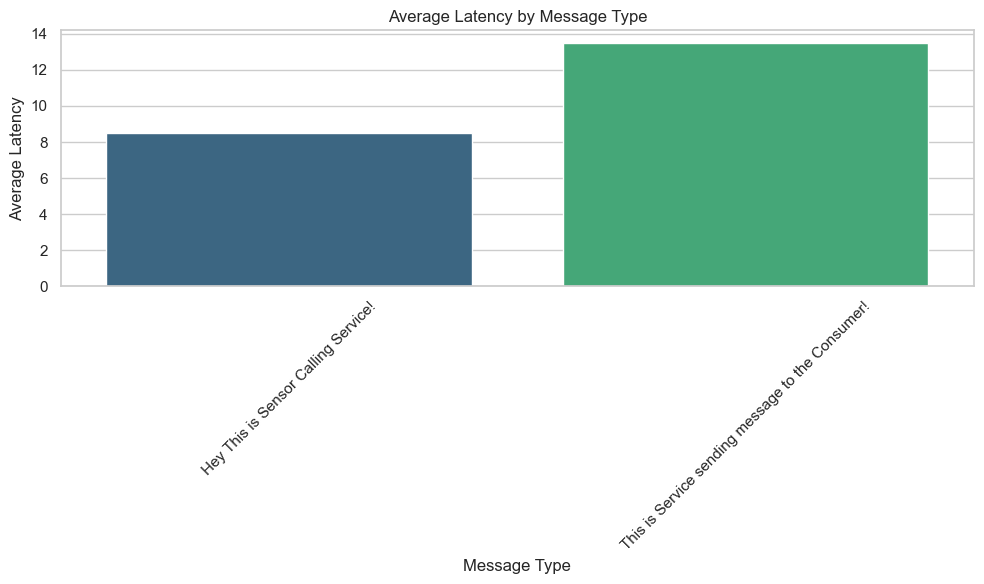

In [6]:
# Visualize Average Latency by Message Type
if 'message' in df.columns and 'latency' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=avg_latency_by_msg, x='message', y='latency', palette='viridis')
    plt.title('Average Latency by Message Type')
    plt.xlabel('Message Type')
    plt.ylabel('Average Latency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

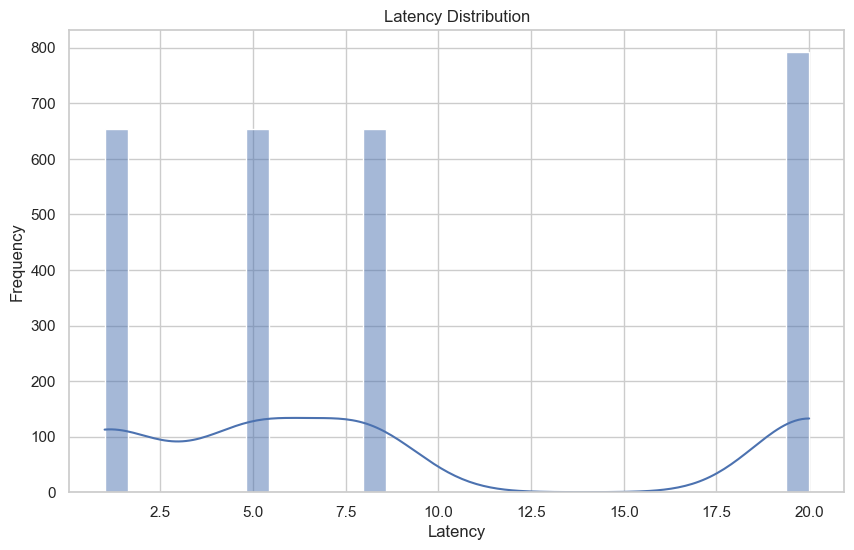

In [7]:
# Visualize Latency Distribution
if 'latency' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['latency'], kde=True, bins=30)
    plt.title('Latency Distribution')
    plt.xlabel('Latency')
    plt.ylabel('Frequency')
    plt.show()

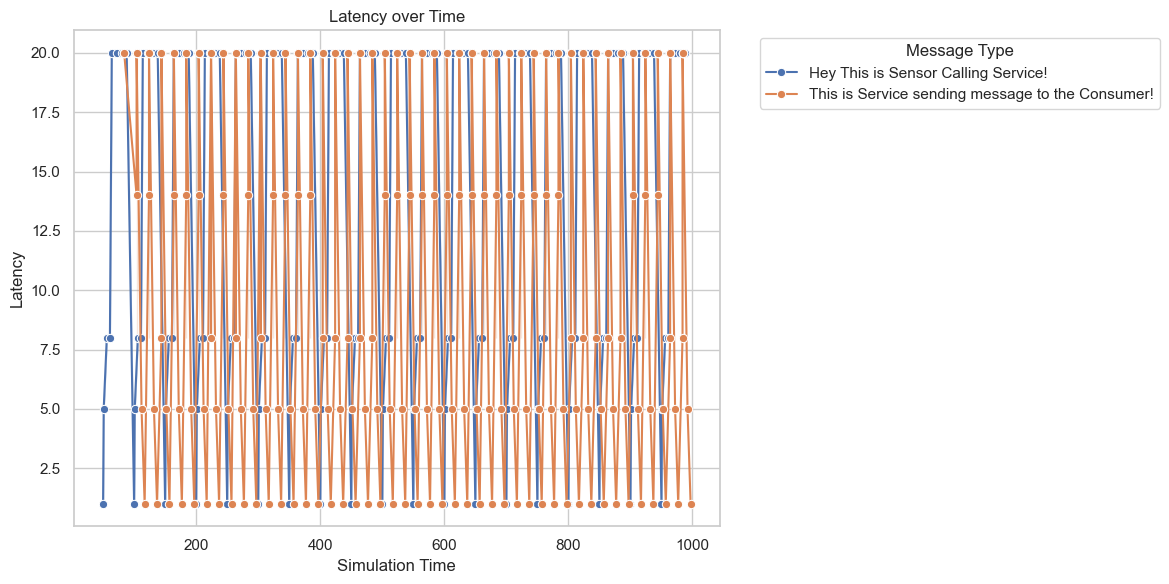

In [8]:
# Visualize Latency Over Time
if 'ctime' in df.columns and 'latency' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='ctime', y='latency', hue='message', marker='o')
    plt.title('Latency over Time')
    plt.xlabel('Simulation Time')
    plt.ylabel('Latency')
    plt.legend(title='Message Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()